In [1]:
%load_ext autoreload
%autoreload 2

In [131]:
import pandas as pd
import sys
import warnings
sys.path.append("A2")
sys.path.append("preprocessing")
import regression_tree as rt
import random_forest as rf
import prediction_evaluation as eval
import grid_search
import parameter_eval
import preprocessing_food_wastage as pre_food_wastage
import preprocessing_college_ranking as pre_college_ranking
import preprocessing_popular_songs as pre_ppl_songs

pd.set_option("display.max_colwidth", None)

# Processing Datasets

Dataset Food Wastage
The full dataframe consists of 1782 rows, and 11 attributes
Rows containing NA values before preprocessing: 0


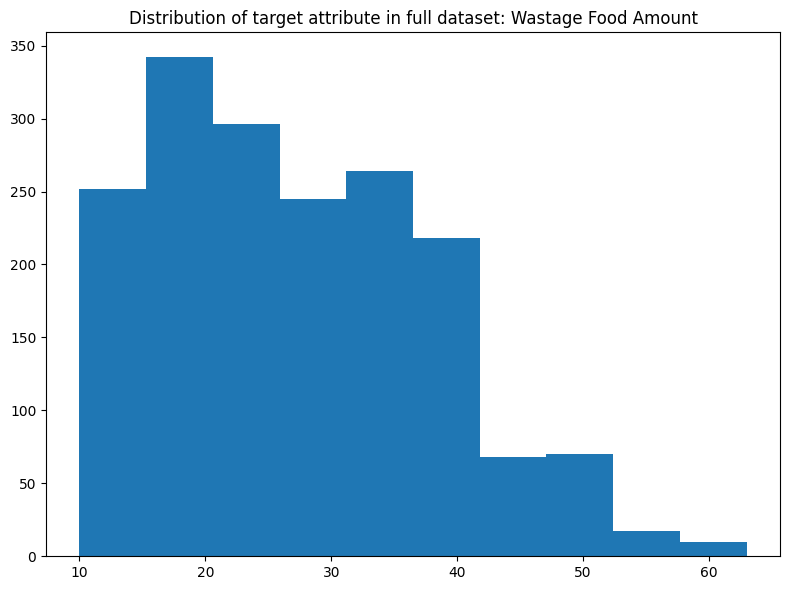

The train dataframe consists of 1188 rows, and 11 attributes


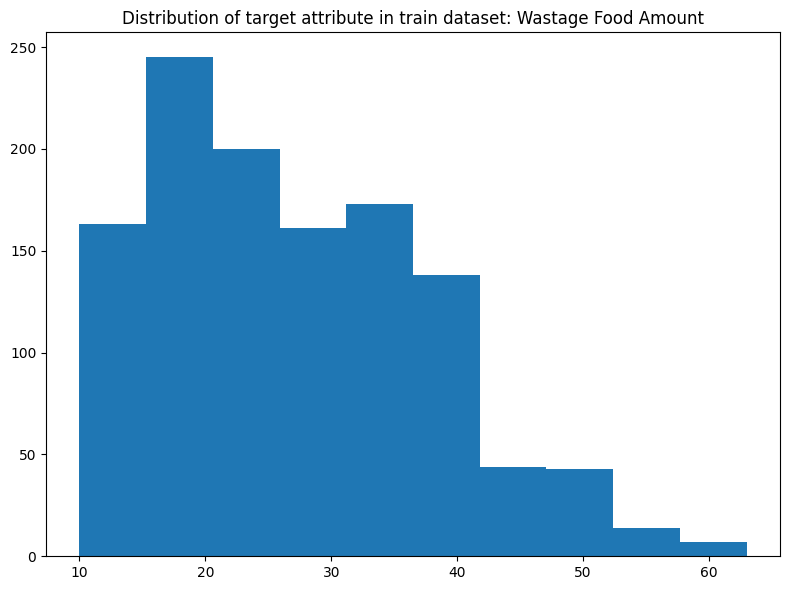

The test dataframe consists of 594 rows, and 11 attributes


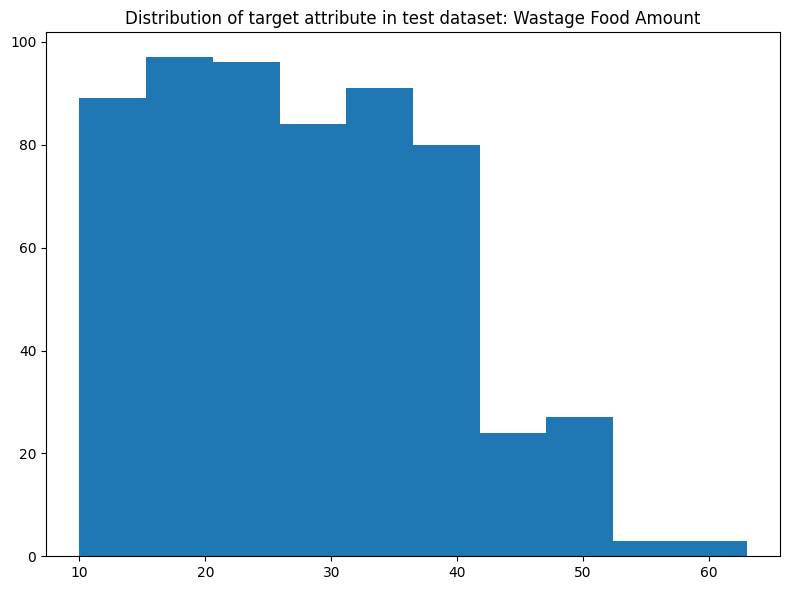

Dataset University Ranking
The full dataframe consists of 167 rows, and 41 attributes
Rows containing NA values before preprocessing: 160


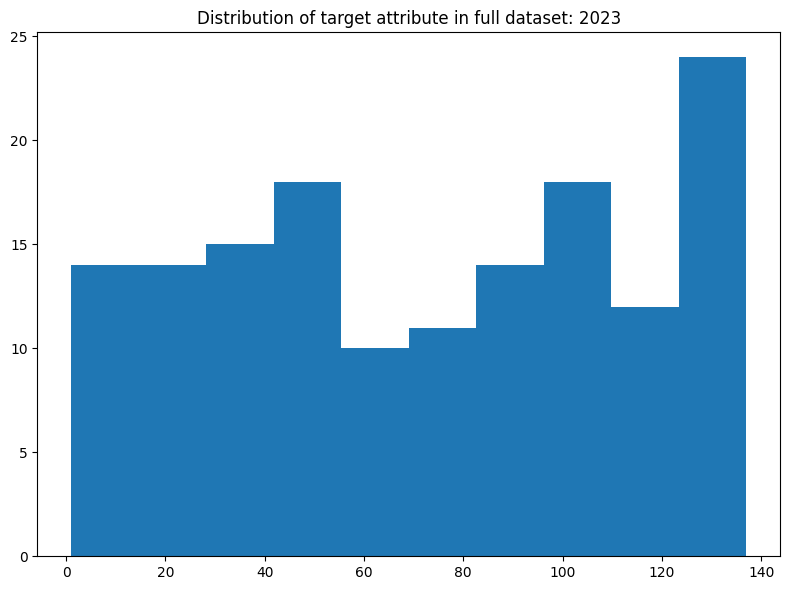

The train dataframe consists of 111 rows, and 41 attributes


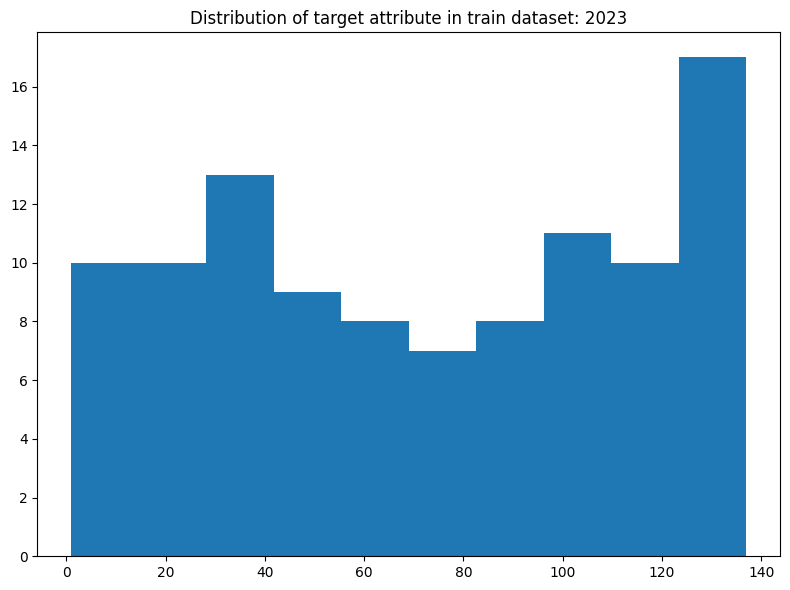

The test dataframe consists of 56 rows, and 41 attributes


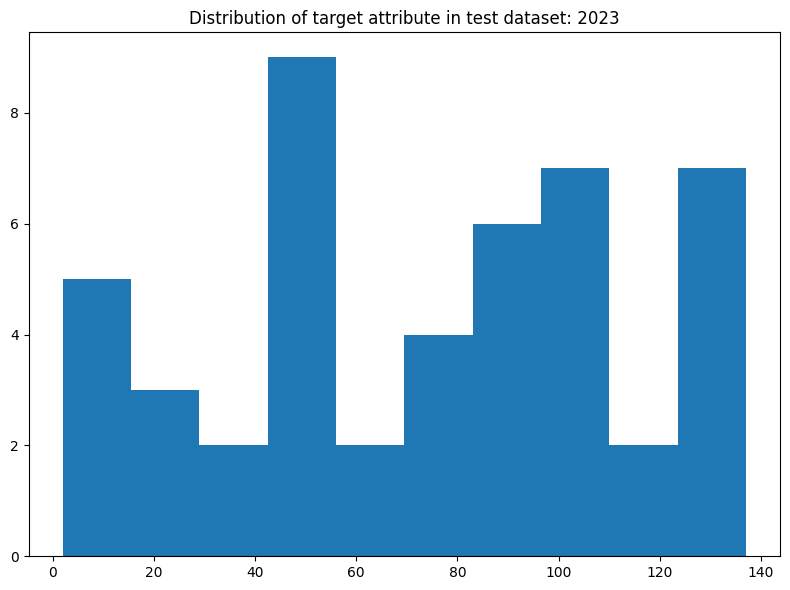

Null values count in the dataset 0
Categorical column "song_name" is at index:  0


In [132]:
warnings.filterwarnings('ignore', category=FutureWarning)

food_waste_df_train, food_waste_df_test = pre_food_wastage.preprocessing_food_wastage()
college_rank_df_train, college_rank_df_test = pre_college_ranking.preprocessing_college_ranking()
popular_songs_features_train, popular_songs_features_test = pre_ppl_songs.preprocessing_polar_songs()

In [234]:
param_grid = {
    'min_samples_split': range(4,16,2),
    'max_depth': range(1,10,2),
    'split_criterion': ['mse', 'sse']
}


param_grid_scikit = {
    'min_samples_split': range(4,16,2),
    'max_depth': range(1,10,2),
    'criterion': ['squared_error']
}


param_grid_rf = {
    'min_samples_split': range(5,7,1),
    'max_depth': range(1,3,1),
    'split_criterion': ['sse', 'mse'],
    'no_of_estimators': range(1,3,2),
    'max_features_criterion': ['sqrt']
}


# Regression Trees

## Food Waste

In [134]:
best_tree_food_waste, train_results_food_waste = grid_search.grid_search_cv2(food_waste_df_train, "wastage_food_amount", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_food_waste.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  7.7min finished


,runtime,mean_rmse,mean_mae,Parameters
0,43.661565,3.260844,2.120995,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"
1,70.217996,3.542926,2.129355,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'sse'}"
2,79.892052,3.723714,2.497201,"{'min_samples_split': 8, 'max_depth': 7, 'split_criterion': 'sse'}"
3,61.577134,3.746507,2.279135,"{'min_samples_split': 6, 'max_depth': 9, 'split_criterion': 'sse'}"
4,104.392896,3.756801,2.369341,"{'min_samples_split': 8, 'max_depth': 9, 'split_criterion': 'sse'}"
5,50.396700,3.826036,2.494022,"{'min_samples_split': 6, 'max_depth': 7, 'split_criterion': 'sse'}"


In [135]:
food_waste_predictions_reg_tree = rt.predict_from_tree(best_tree_food_waste, food_waste_df_test)
food_waste_rmse_reg_tree = eval.rmse(food_waste_df_test["wastage_food_amount"], food_waste_predictions_reg_tree)
print(f"RMSE score on test set: {food_waste_rmse_reg_tree}")


RMSE score on test set: 3.050349435526631


In [219]:
train_results_food_waste_scikit, best_tree_scikit_food_waste = grid_search.grid_search_scikit(food_waste_df_train, "wastage_food_amount", param_grid_scikit)
train_results_food_waste_scikit.loc[:5,]


Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=9, min_samples_split=14, random_state=1)
Time(s):  0.8795177999418229


,runtime,mean_rmse,mean_mae,Parameters
0,0.879518,3.202585,1.939226,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 14}"
1,0.879518,3.203612,1.914761,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 12}"
2,0.879518,3.213652,1.889940,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 10}"
3,0.879518,3.244165,1.879883,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
4,0.879518,3.286388,2.099310,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 6}"
5,0.879518,3.292443,2.100718,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 4}"


In [220]:
food_waste_predictions_reg_tree_scikit = best_tree_scikit_food_waste.predict(food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])
food_waste_rmse_reg_tree_scikit = eval.rmse(food_waste_df_test["wastage_food_amount"], food_waste_predictions_reg_tree_scikit)
print(f"Food waste RMSE score on test set: {food_waste_rmse_reg_tree}")
print(f"Food waste RMSE score on test set using Scikit implementation: {food_waste_rmse_reg_tree_scikit}")

Food waste RMSE score on test set: 3.050349435526631
Food waste RMSE score on test set using Scikit implementation: 3.1985216148270506


## College Rank

## Grid Search and CV

### Our Implementation

In [186]:
best_tree_college_rank, train_results_college_rank = grid_search.grid_search_cv2(college_rank_df_train, "2023", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_college_rank.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   33.6s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  1.7min finished


,runtime,mean_rmse,mean_mae,Parameters
0,4.998084,9.178802,7.429202,"{'min_samples_split': 4, 'max_depth': 3, 'split_criterion': 'sse'}"
1,13.813458,9.316178,6.941028,"{'min_samples_split': 4, 'max_depth': 5, 'split_criterion': 'sse'}"
2,7.833440,9.704047,8.069895,"{'min_samples_split': 6, 'max_depth': 5, 'split_criterion': 'sse'}"
3,4.944218,9.866576,8.159236,"{'min_samples_split': 4, 'max_depth': 3, 'split_criterion': 'mse'}"
4,19.303758,10.001734,8.033945,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'sse'}"
5,5.742125,10.119735,8.226652,"{'min_samples_split': 8, 'max_depth': 5, 'split_criterion': 'sse'}"


### Scikit-learn Implementation

In [217]:
train_results_college_rank_scikit, best_tree_scikit_college_rank = grid_search.grid_search_scikit(college_rank_df_train, "2023", param_grid_scikit)
train_results_college_rank_scikit.loc[:5,]


Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=5, min_samples_split=8, random_state=1)
Time(s):  0.7129336999496445


,runtime,mean_rmse,mean_mae,Parameters
0,0.712934,9.962908,7.933744,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 8}"
1,0.712934,10.119857,8.261271,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 12}"
2,0.712934,10.159822,8.173889,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 10}"
3,0.712934,10.237771,8.173559,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
4,0.712934,10.254054,8.169620,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 8}"
5,0.712934,10.329612,8.328360,"{'criterion': 'squared_error', 'max_depth': 3, 'min_samples_split': 10}"


## Predictions on test set

In [218]:
college_rank_predictions_reg_tree = rt.predict_from_tree(best_tree_college_rank, college_rank_df_test)
college_rank_rmse_reg_tree, college_rank_mae_reg_tree = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_reg_tree)
print(f"College Rank scores on test set using our implementation. RMSE: {college_rank_rmse_reg_tree}, MAE: {college_rank_mae_reg_tree}")

college_rank_predictions_reg_tree_scikit = best_tree_scikit_college_rank.predict(college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])
college_rank_rmse_reg_tree_scikit, college_rank_mae_reg_tree_scikit = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_reg_tree_scikit)
print(f"College Rank scores on test set using Scikit implementation. RMSE: {college_rank_rmse_reg_tree_scikit}, MAE: {college_rank_mae_reg_tree_scikit}")


College Rank scores on test set using our implementation. RMSE: 9.09345051351018, MAE: 7.23078231292517
College Rank scores on test set using Scikit implementation. RMSE: 10.103077791391781, MAE: 8.038446969696968


## Popular Songs

## CV and Grid Search


In [145]:
best_tree_popular_songs, train_results_popular_songs = grid_search.grid_search_cv2(popular_songs_features_train, "song_popularity", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_popular_songs

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  3.8min


KeyboardInterrupt: 

### Predictions on Test Set

In [ ]:
college_rank_predictions_reg_tree = rt.predict_from_tree(best_tree_college_rank, college_rank_df_test)
college_rank_rmse_reg_tree = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_reg_tree, "rmse")
print(f"College rank RMSE score on test set: {college_rank_rmse_reg_tree}")

### 

# Random Forest

For Random forest, we do not need to use CV, because then we loose the OOB data for each bootstrap. So we do OOB eval instead with the same grid.

## Food Waste

### OOB Testing

In [235]:
best_forest, train_results_rf_food_waste = grid_search.grid_search_obb(food_waste_df_train, "wastage_food_amount", param_grid_rf)
train_results_rf_food_waste

Running combo: 1 out of: 8
Running combo: 2 out of: 8
Running combo: 3 out of: 8
Running combo: 4 out of: 8
Running combo: 5 out of: 8
Running combo: 6 out of: 8
Running combo: 7 out of: 8
Running combo: 8 out of: 8


,runtime,mean_score,Parameters
0,0.209131,6.715378,"{'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'mse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
1,0.226174,6.988964,"{'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
2,0.202150,8.418613,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
3,0.152429,8.764838,"{'min_samples_split': 6, 'max_depth': 1, 'split_criterion': 'sse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
4,0.205401,9.381425,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'mse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
5,0.137149,10.351431,"{'min_samples_split': 5, 'max_depth': 1, 'split_criterion': 'mse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"


In [73]:
food_waste_predictions_random_forest = rf.predict_from_forest(food_waste_df_test, best_forest)
food_waste_rmse_random_forest = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_random_forest, "rmse")
print(f"RMSE score on test set: {food_waste_rmse_random_forest}")

RMSE score on test set: 6.24744624914428


# Hyperparameter Sensitivity Evaluation

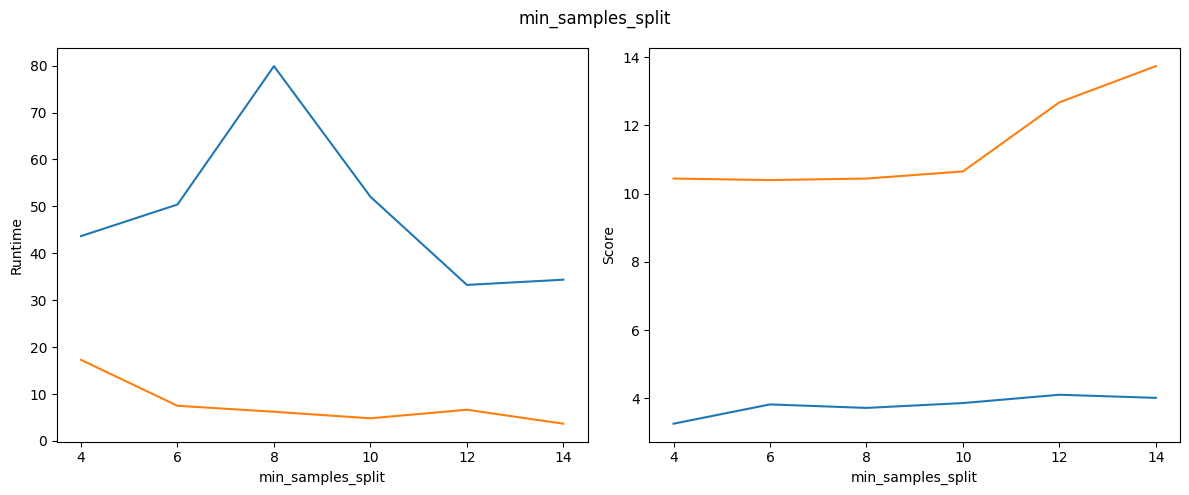

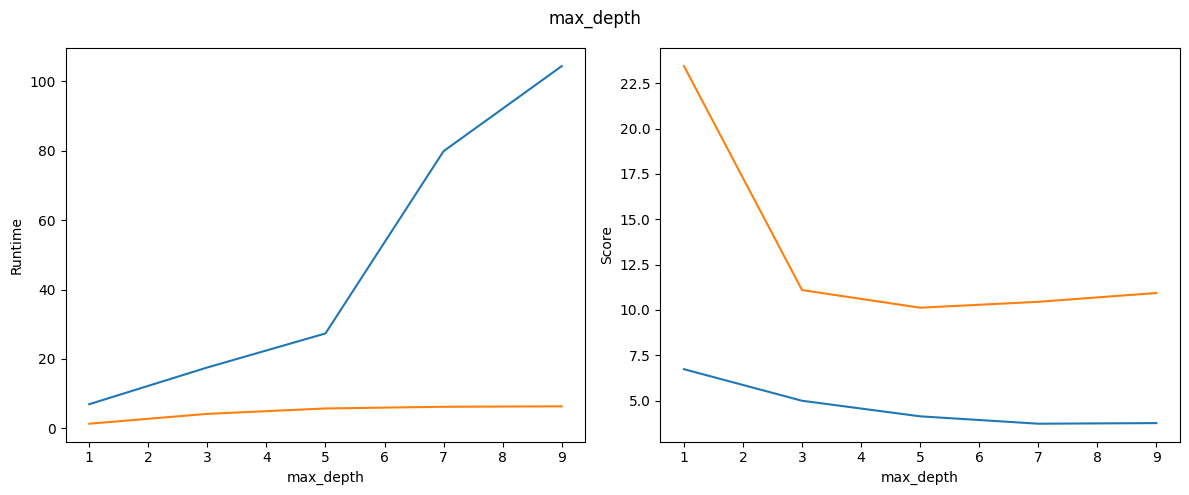

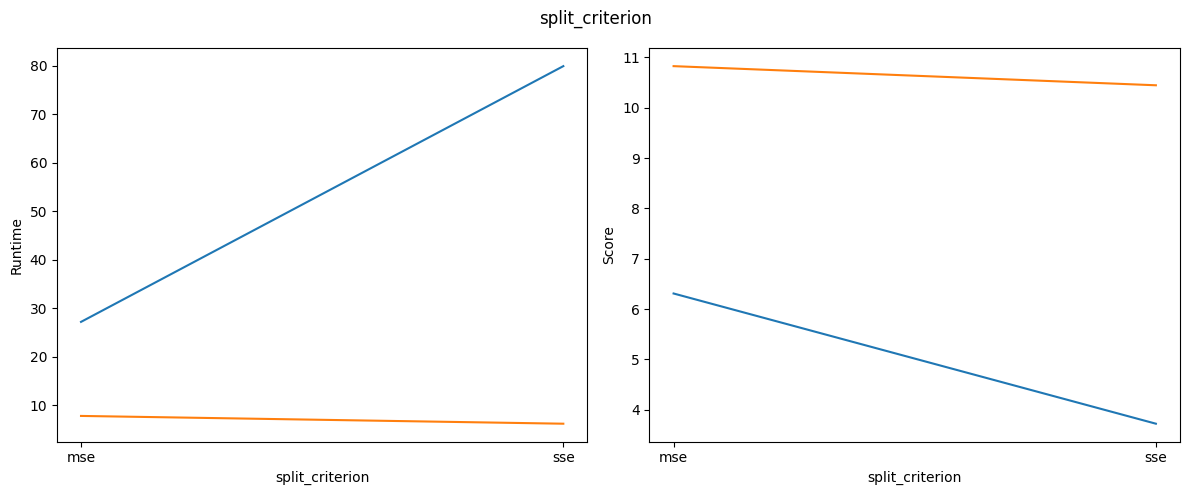

In [221]:
eval_param = {
    'min_samples_split': 8,
    'max_depth': 7,
    'split_criterion': 'sse'
}

parameter_eval.plot_parameter(train_results_food_waste, train_results_college_rank, param_grid, eval_param)



# Big Table

In [233]:

all_train_results = pd.concat([
    train_results_food_waste.loc[[0]].assign(algorithm="Regression Tree", dataset="Food Wastage", implementation="Ours"),
    train_results_food_waste_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="Food Wastage", implementation="Scikit"),
    train_results_college_rank.loc[[0]].assign(algorithm="Regression Tree", dataset="University Rank", implementation="Ours"),
    train_results_college_rank_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="University Rank", implementation="Scikit"),
    #train_results_popular_songs.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Ours")
    #train_results_popular_songs_scikit.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Scikit"),

]).reset_index(drop=True)
all_train_results = all_train_results.join(all_train_results['Parameters'].apply(pd.Series))

index_to_fix = ~all_train_results["criterion"].isna()
all_train_results.loc[index_to_fix, "split_criterion"] = all_train_results.loc[index_to_fix, "criterion"]

all_train_results = all_train_results.drop(["Parameters", "criterion"], axis=1)
all_train_results_reorderd = all_train_results[["runtime", "mean_rmse", "mean_mae", "min_samples_split", "max_depth", "split_criterion", "algorithm", "dataset", "implementation"]]

all_train_results_reorderd

,runtime,mean_rmse,mean_mae,min_samples_split,max_depth,split_criterion,algorithm,dataset,implementation
0,43.661565,3.260844,2.120995,4,7,sse,Regression Tree,Food Wastage,Ours
1,0.879518,3.202585,1.939226,14,9,squared_error,Regression Tree,Food Wastage,Scikit
2,4.998084,9.178802,7.429202,4,3,sse,Regression Tree,University Rank,Ours
3,0.712934,9.962908,7.933744,8,5,squared_error,Regression Tree,University Rank,Scikit
